# Event-related potentials

With our data segmented into intervals around events of interest (aka trials), we can aggregate the neural data across many trials and subjects, and compare and contrast it between different experimental conditions. The objective in our analysis is to characterize time and location where neural signature correlates significantly with a cognitive process.

Averaging EEG signals attenuates the (zero-mean) noise present in individual trials, and yields us a stable, stereotypical response to the experimental event present in the trials - the evoked potential.


In [1]:
import mne
from glob import glob as ls
import matplotlib.pyplot as plt
import numpy as np, pandas as pd

## Configuration
We prepare a few parameters that control how much we smooth out the final ERP (`fmin`,`fmax`), and the way in which we partition the trials sets into conditions to compare. In the current example this will be by the set size (`size`, `cond`). `cond` prepares a filter for the table of metadata we created during trial segmentation, we could also filter on e.g. response time or correct/incorrect response, or a combination of multiple trial properties.

In [64]:
bsl = (-.2,0)
fmin = 1; fmax = 20
size = [1,2,4]
cond = lambda s: f"Size=={s}"

## ERP Computation
Note how we select the files to use in the main step - in addition to the extension for epoched data (`-epo.fif.gz`), we added the term `stim` to find the stimulus-locked files. We may choose to select different file sets for different analyses. Right now, we suspect we may find a difference in the way stimuli are processed depending on the memory load (set size).

Once the file is loaded, computing the ERP is straightforward: filtering, averaging across trials, and baselining. The steps are so simple that we skip saving the results for now.

In [2]:
files = [f for f in sorted(ls("Data/s03/*stim-epo.fif.gz"))];files

['Data/s03/dmss03_stim-epo.fif.gz']

In [3]:
evoked = {}
for f in files:
    evoked[f] = {}
    epoch = mne.read_epochs(f,preload=True)
    for s in size:
        evoked[f][cond(s)] = epoch[cond(s)].filter(fmin,fmax).average().apply_baseline(bsl);

Reading /Users/fbaumg/Documents/Obsidian/Courses/PS329/Data/s03/dmss03_stim-epo.fif.gz ...
    Found the data of interest:
        t =    -700.00 ...    1700.00 ms
        0 CTF compensation matrices available
Adding metadata with 5 columns
690 matching events found
No baseline correction applied
0 projection items activated
Setting up band-pass filter from 1 - 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 20.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 22.50 Hz)
- Filter length: 3301 samples (3.301 s)



/var/folders/9z/wdzscs1d11s28758n1wm54wh00_b1l/T/ipykernel_34483/1088930980.py:7: RuntimeWarning: filter_length (3301) is longer than the signal (2401), distortion is likely. Reduce filter length or filter a longer signal.
  evoked[f][cond] = epoch[cond].filter(1,20).average().apply_baseline((-.2,0));


Applying baseline correction (mode: mean)
Setting up band-pass filter from 1 - 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 20.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 22.50 Hz)
- Filter length: 3301 samples (3.301 s)



/var/folders/9z/wdzscs1d11s28758n1wm54wh00_b1l/T/ipykernel_34483/1088930980.py:7: RuntimeWarning: filter_length (3301) is longer than the signal (2401), distortion is likely. Reduce filter length or filter a longer signal.
  evoked[f][cond] = epoch[cond].filter(1,20).average().apply_baseline((-.2,0));


Applying baseline correction (mode: mean)
Setting up band-pass filter from 1 - 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 20.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 22.50 Hz)
- Filter length: 3301 samples (3.301 s)



/var/folders/9z/wdzscs1d11s28758n1wm54wh00_b1l/T/ipykernel_34483/1088930980.py:7: RuntimeWarning: filter_length (3301) is longer than the signal (2401), distortion is likely. Reduce filter length or filter a longer signal.
  evoked[f][cond] = epoch[cond].filter(1,20).average().apply_baseline((-.2,0));


Applying baseline correction (mode: mean)


## ERP Analysis

### Global

We now have an object `evoked` that contains 3 evoked potentials for each file. Below is a first glance at the result.

Compared to the previous notebook, we may notice slightly less flat baseline periods due to the smaller number of trials per condition. We also notice a different shape of the P300 ERP between the different memory load conditions.

Using the color code for the sensor locations, we observe that the ERPs appear particularly characteristic in the left posterior region.

No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.


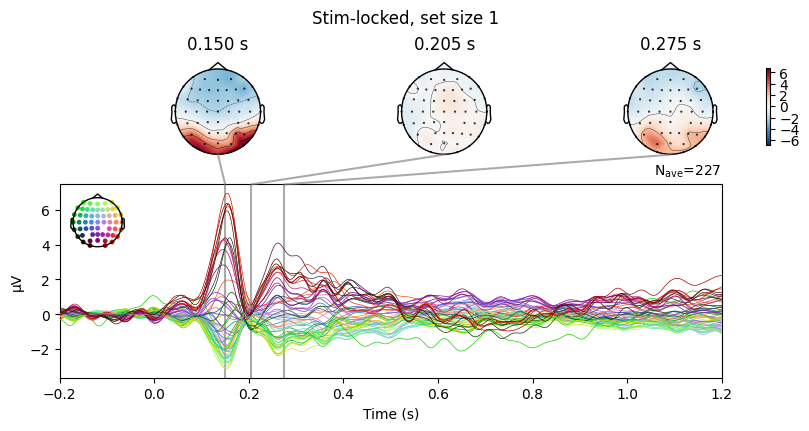

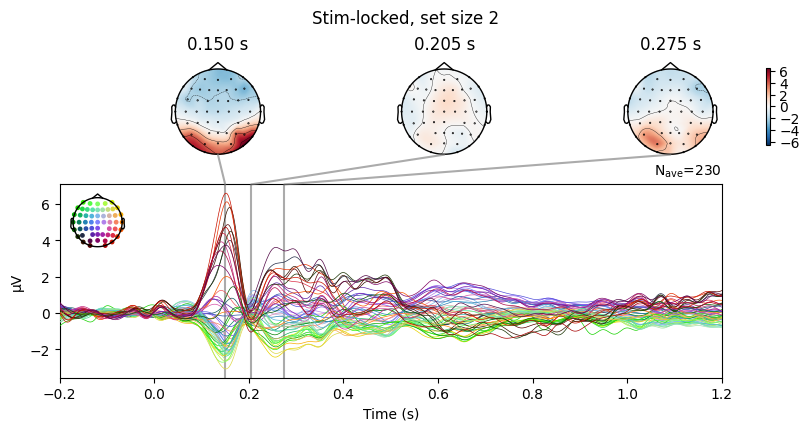

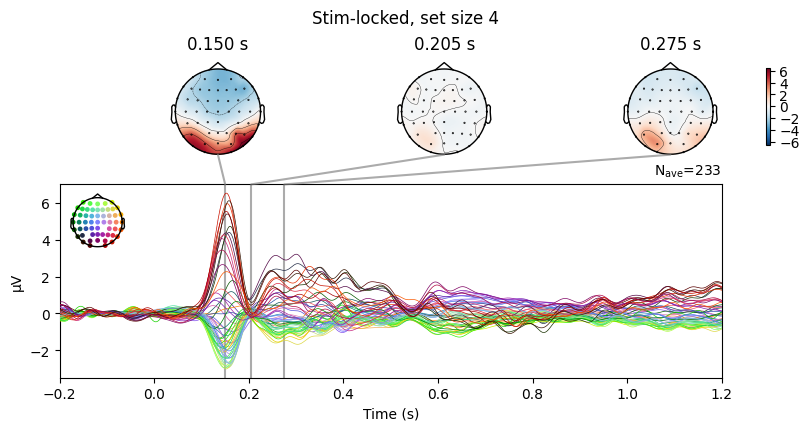

In [4]:
f = files[0]
for k,v in evoked[f].items():
    v.plot_joint(times=[0.15,0.205,0.275],ts_args={'xlim':(-.2,1.2)},title=f"Stim-locked, set size {k[-1]}",show=False)

### Local

With the information about specific locations or time intervals, we may focus in on areas of noticable difference between the conditions. We extract the EEG from a focused set of sensors and plot multiple conditions in a single graph.

In [65]:
ts = epoch.copy().crop(-.2,1.2).times
erp = np.squeeze([epoch[f'size{s}'].filter(1,10).apply_baseline((-.2,0)).average().crop(-.2,1.2).get_data(picks=['PO3']) for s in [1,2,4]])

Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 11.25 Hz)
- Filter length: 3301 samples (3.301 s)



/var/folders/9z/wdzscs1d11s28758n1wm54wh00_b1l/T/ipykernel_34483/3124416825.py:2: RuntimeWarning: filter_length (3301) is longer than the signal (2401), distortion is likely. Reduce filter length or filter a longer signal.
  erp = np.squeeze([epoch[f'size{s}'].filter(1,10).apply_baseline((-.2,0)).average().crop(-.2,1.2).get_data(picks=['PO3']) for s in [1,2,4]])


Applying baseline correction (mode: mean)
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 11.25 Hz)
- Filter length: 3301 samples (3.301 s)



/var/folders/9z/wdzscs1d11s28758n1wm54wh00_b1l/T/ipykernel_34483/3124416825.py:2: RuntimeWarning: filter_length (3301) is longer than the signal (2401), distortion is likely. Reduce filter length or filter a longer signal.
  erp = np.squeeze([epoch[f'size{s}'].filter(1,10).apply_baseline((-.2,0)).average().crop(-.2,1.2).get_data(picks=['PO3']) for s in [1,2,4]])


Applying baseline correction (mode: mean)
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 11.25 Hz)
- Filter length: 3301 samples (3.301 s)



/var/folders/9z/wdzscs1d11s28758n1wm54wh00_b1l/T/ipykernel_34483/3124416825.py:2: RuntimeWarning: filter_length (3301) is longer than the signal (2401), distortion is likely. Reduce filter length or filter a longer signal.
  erp = np.squeeze([epoch[f'size{s}'].filter(1,10).apply_baseline((-.2,0)).average().crop(-.2,1.2).get_data(picks=['PO3']) for s in [1,2,4]])


Applying baseline correction (mode: mean)


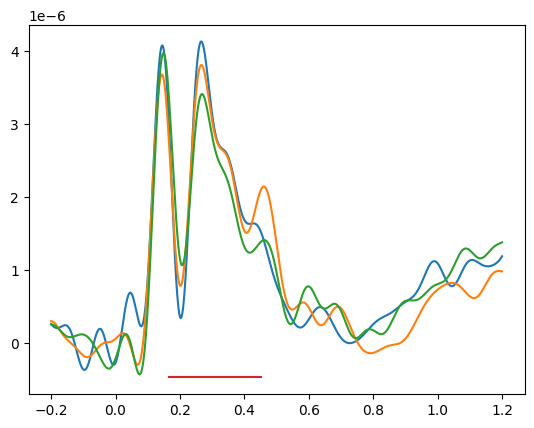

In [66]:
plt.plot(ts,erp.T);
plt.plot(sig_ts,sig_y);

### Statistics

A more numerically grounded approach is to identify the regions where conditions differ computationally. We can do this by looking for statistically significant differences between conditions using hypothesis tests. A common problem with EEG (and other neural data) is that we have to perform many tests, which leads to false positives. Below we perform a corrected test with permutation testing - creating a distribution by shuffling the data many times, then checking how likely the actual measurement is. We will go into deeper detail on statistics in later classes.

In [58]:
cond1='size1'
cond2='size4'
bsl = (-.2,0)
tmin=-.2; tmax=1.2
fmin=1; fmax=20
x1 = epoch[cond1].filter(fmin,fmax).apply_baseline(bsl).crop(tmin,tmax).get_data().transpose(0,2,1)
x2 = epoch[cond2].filter(fmin,fmax).apply_baseline(bsl).crop(tmin,tmax).get_data().transpose(0,2,1)
_, clusters, pvals, _ = mne.stats.permutation_cluster_test([x1,x2], out_type='mask')
clusters = [c for p,c in zip(pvals,clusters) if p<.05]

Setting up band-pass filter from 1 - 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 20.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 22.50 Hz)
- Filter length: 3301 samples (3.301 s)



/var/folders/9z/wdzscs1d11s28758n1wm54wh00_b1l/T/ipykernel_34483/3720916576.py:5: RuntimeWarning: filter_length (3301) is longer than the signal (2401), distortion is likely. Reduce filter length or filter a longer signal.
  x1 = epoch[cond1].filter(1,20).apply_baseline(bsl).crop(tmin,tmax).get_data().transpose(0,2,1)


Applying baseline correction (mode: mean)
Setting up band-pass filter from 1 - 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 20.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 22.50 Hz)
- Filter length: 3301 samples (3.301 s)



/var/folders/9z/wdzscs1d11s28758n1wm54wh00_b1l/T/ipykernel_34483/3720916576.py:6: RuntimeWarning: filter_length (3301) is longer than the signal (2401), distortion is likely. Reduce filter length or filter a longer signal.
  x2 = epoch[cond2].filter(1,20).apply_baseline(bsl).crop(tmin,tmax).get_data().transpose(0,2,1)


Applying baseline correction (mode: mean)
Using a threshold of 3.861842
stat_fun(H1): min=3.665003344493776e-10 max=28.869238824954163
Running initial clustering …
Found 116 clusters


/var/folders/9z/wdzscs1d11s28758n1wm54wh00_b1l/T/ipykernel_34483/3720916576.py:7: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters, pvals, _ = mne.stats.permutation_cluster_test([x1,x2], out_type='mask')
100%|█████████████████████████| Permuting : 1023/1023 [01:19<00:00,   12.85it/s]


In [60]:
# Create a spatial (ch_msk) and a temporal (sig_ts) mask for statistical differences between conditions
msk = np.sum(clusters,0)
ch_msk = msk.sum(0)>0
ts_msk = msk.sum(1)>0
sig_ts = evk.copy().crop(-.2,1.2).times[ts_msk]
sig_y = np.ones_like(sig_ts)*np.min([np.min(erp)*.9,np.min(erp)*1.1])

In [68]:
ch_dat = x2[:,ts_msk,:].mean((0,1))-x1[:,ts_msk,:].mean((0,1))
ts_dat = x2[:,:,ch_msk].mean((0,2))-x1[:,:,ch_msk].mean((0,2))

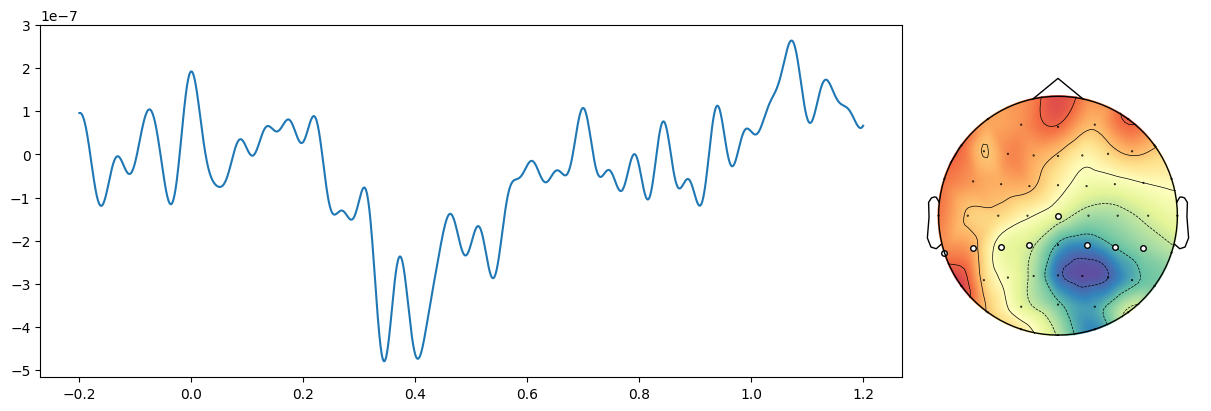

In [71]:
fig = plt.figure(figsize=(12, 4), layout="constrained")
gs = fig.add_gridspec(1, 2, width_ratios=[3,1])
ax_erp = fig.add_subplot(gs[0, 0])
ax_top = fig.add_subplot(gs[0, 1])
ax_erp.plot(ts,ts_dat)
mne.viz.plot_topomap(ch_dat,epoch.info,cmap='Spectral_r',mask=ch_msk,axes=ax_top,show=False);

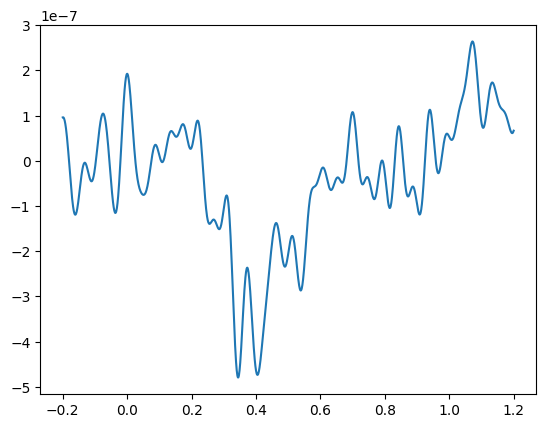